# Edge-of-Chaos: demonstration notebook

This notebook runs the software that accompanies the research programme *Necessary
Conditions for Primary Interoceptive Sentience in Continuous Substrates: A Falsifiable
Programme* ([doi:10.5281/zenodo.22895484](https://doi.org/10.5281/zenodo.22895484)).

Everything below runs on **simulated or synthetic data**. Nothing here is a measurement
of a physical substrate, and no result shown is evidence for or against the programme.
The purpose is to show what each quantity computes, how the criteria separate cases whose
answer is known, and where the current software has limits.

1. The valence proxy Ψ(t) and the efference-copy ablation
2. The predictive gain G_pred and its known limit
3. The three operational demarcation conditions
4. A necessary condition: local activity at the edge of chaos

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # repository root

import numpy as np
import matplotlib.pyplot as plt

from thermodynamic_valence import simulate_neuromorphic_substrate_sde, calculate_thermodynamic_valence
from demarcation import residual_memory, non_markovian_memory, state_dependent_dynamics
from necessary_conditions import edge_of_chaos, first_order_admittance
from synthetic_systems import ar1, nonlinear_lag5, linear_2d, double_well

## 1. The valence proxy Ψ(t) and the efference-copy ablation

The digital twin integrates a one-variable stochastic model of the substrate (level A1)
and a prediction of its next state (the efference copy of level A2). It computes a
**practical proxy** of Ψ(t), not the formal functional of the paper, whose normalisation
needs a hardware calibration (P1, Appendix F).

The protocol predicts that ablating the efference copy lowers Ψ. Here the ablation
replaces the prediction with noise. Note that in this simulation A2 does not feed back
into A1: the ablation changes the measurement, not the dynamics.

g_pred       baseline   4.466   ablated   1.812
psi_valence  baseline   1.948   ablated  -0.175


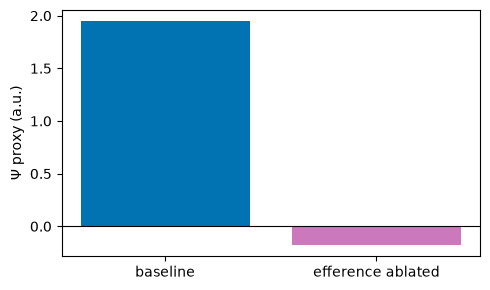

In [2]:
x, s_obs, s_pred, dt = simulate_neuromorphic_substrate_sde(n_steps=2000, seed=42)
ablated = np.random.default_rng(2026).normal(0, 1, len(s_pred))

base = calculate_thermodynamic_valence(x, s_obs, s_pred, dt)
abl = calculate_thermodynamic_valence(x, s_obs, ablated, dt)
for key in ("g_pred", "psi_valence"):
    print(f"{key:12s} baseline {base[key]:7.3f}   ablated {abl[key]:7.3f}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["baseline", "efference ablated"], [base["psi_valence"], abl["psi_valence"]], color=["#0173B2", "#CC78BC"])
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Ψ proxy (a.u.)")
plt.tight_layout()

## 2. The predictive gain G_pred and its known limit

G_pred follows the definition of the self-agency paper (P2, section 5.4):
`D_KL(p_obs || p_ref) - D_KL(p_obs || p_pred)`, on delay-embedded densities
`(s(t), s(t - tau))`. It rewards a prediction whose distribution matches that of the
observations.

Because the two densities are estimated separately, G_pred cannot tell whether the
prediction is **aligned in time** with the observations: a prediction delayed by 200
steps scores the same as the correct one. In the protocol, temporal alignment is covered
by a separate transfer-entropy requirement, which the software does not implement.

In [3]:
cases = {
    "correct prediction": s_pred,
    "delayed by 200 steps": np.roll(s_pred, 200),
    "shuffled in time": np.random.default_rng(1).permutation(s_pred),
    "noise": ablated,
}
for tau in (1, 10, 50):
    values = {name: calculate_thermodynamic_valence(x, s_obs, pred, dt, tau_steps=tau)["g_pred"] for name, pred in cases.items()}
    print(f"tau = {tau:3d}: " + ", ".join(f"{name} {value:.2f}" for name, value in values.items()))

tau =   1: correct prediction 3.86, delayed by 200 steps 3.86, shuffled in time 4.09, noise 1.79
tau =  10: correct prediction 4.47, delayed by 200 steps 4.46, shuffled in time 4.22, noise 1.81
tau =  50: correct prediction 4.56, delayed by 200 steps 4.56, shuffled in time 4.04, noise 1.52


## 3. The three operational demarcation conditions

A substrate is a candidate only if all three conditions hold (P0, section 3). Each is
shown on a synthetic system that should pass and one that should fail.

**Condition 2, non-Markovian memory.** For each Markov order k, the information that the
past beyond the k most recent states carries about the future, compared with IAAFT
surrogates. The process with nonlinear lag-5 memory keeps residual memory up to order 4;
the AR(1) process has none beyond order 0. Surrogate settings are reduced for speed (the
protocol uses 100 surrogates and the 99th percentile).

nonlinear, lag-5 memory    passes condition 2 (k_max = 3): True


AR(1), Markov              passes condition 2 (k_max = 3): False


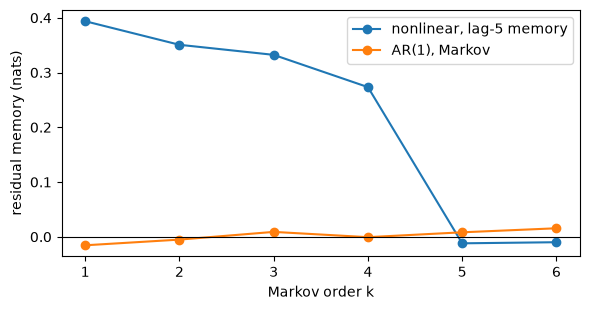

In [4]:
series = {"nonlinear, lag-5 memory": nonlinear_lag5(1500), "AR(1), Markov": ar1(1500)}
orders = range(1, 7)
fig, ax = plt.subplots(figsize=(6, 3.2))
for name, s in series.items():
    ax.plot(list(orders), [residual_memory(s, k, past_lags=5) for k in orders], "o-", label=name)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Markov order k")
ax.set_ylabel("residual memory (nats)")
ax.legend()
plt.tight_layout()

for name, s in series.items():
    result = non_markovian_memory(s, k_max=3, n_surrogates=19, percentile=95)
    print(f"{name:26s} passes condition 2 (k_max = 3): {result['passes']}")

**Condition 3, state-dependent dynamics.** The effective Jacobian is estimated in three
regions of phase space. A linear system has the same Jacobian everywhere; a double well
does not.

In [5]:
for name, states in {"double well": double_well(20000), "linear system": linear_2d(20000)}.items():
    result = state_dependent_dynamics(states)
    diffs = ", ".join(f"{d['relative_difference']:.2f}" for d in result["differences"])
    print(f"{name:14s} pairwise relative differences {diffs} -> passes: {result['passes']}")

double well    pairwise relative differences 1.23, 0.05, 1.22 -> passes: True
linear system  pairwise relative differences 0.06, 0.06, 0.11 -> passes: False


## 4. A necessary condition: local activity at the edge of chaos

A device is at the edge of chaos in Chua's sense when its small-signal admittance has a
band with Re Y(jω) < 0 (it can amplify small signals) while its operating point is
asymptotically stable. The example uses a first-order memristive admittance
`Y(s) = g0 + gain / (s + rate)`.

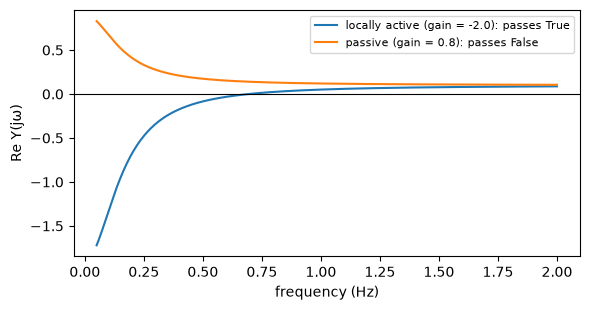

In [6]:
freqs = np.linspace(0.05, 2.0, 400)
fig, ax = plt.subplots(figsize=(6, 3.2))
for label, gain in (("locally active (gain = -2.0)", -2.0), ("passive (gain = 0.8)", 0.8)):
    y = first_order_admittance(freqs, g0=0.1, gain=gain, rate=1.0)
    result = edge_of_chaos(freqs, y, jacobian=[[-1.0]])
    ax.plot(freqs, y.real, label=f"{label}: passes {result['passes']}")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("Re Y(jω)")
ax.legend(fontsize=8)
plt.tight_layout()

## Where to go next

- The command-line interface runs the same demonstrations: `python paper0_cli.py demarcation`,
  `python paper0_cli.py conditions`, `python paper0_cli.py dashboard`.
- The known limits of the software are listed in `CHANGELOG.md`.
- The papers of the programme are in the Zenodo community
  [edge-of-chaos-programme](https://zenodo.org/communities/edge-of-chaos-programme).